# EDA - Offers
Esse notebook aplica uma breve EDA sobre offers.json para entender o tipo de dado presente neste arquivo, quantidade, colunas, tipos de oferta, e outras informações relevantes para o problema e para o processamento de dados.

Abaixo é possível observar alguns pontos interessantes:
1. `informational` possui sempre `min_value=0` e `discount_value=0`. Isso é importante pois não existe recompensa nem valor mínimo, ou seja, a regra `offer completed` não existe para esse tipo específico. O sucesso de `informational` só pode ser medido por transação dentro da janela de duração __após__ o `offer viewed`, não por `offer completed`.
2. `bogo`, em média, possui generosidade igual a 1. Ou seja, "compre X e leve X grátis" está acontecendo.
3. `discount`, em média, tem uma generosidade variável menor. Ou seja, é uma oferta "menos generosa" que o `bogo`.
4. Existe uma relação entre `duration x min_value` dentro de `discount`. Quanto maior é o `min_value`, maior é a `duration`.
5. Geralmente, a oferta `informational` tem durações um pouco mais curtas. O que faz sentido, se levarmos em conta que talvez não exista realmente uma exigência de conversão neste caso, apenas um caráter mais informativo.
6. Todas as ofertas usam `email` e a maioria usa `mobile`.

In [17]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Sessao Spark
spark = SparkSession.builder.appName("ifood-case").getOrCreate()

In [ ]:
# Leitura do arquivo offers.json
offers = spark.read.option("multiline", "true").json("../data/raw/offers.json")

In [ ]:
# Exibicao do schema do arquivo offers.json (por ser pequeno, optei por exibi-lo completo)
offers.show(truncate=False)

+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|channels                    |discount_value|duration|id                              |min_value|offer_type   |
+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|[email, mobile, social]     |10            |7.0     |ae264e3637204a6fb9bb56bc8210ddfd|10       |bogo         |
|[web, email, mobile, social]|10            |5.0     |4d5c57ea9a6940dd891ad53e9dbe8da0|10       |bogo         |
|[web, email, mobile]        |0             |4.0     |3f207df678b143eea3cee63160fa8bed|0        |informational|
|[web, email, mobile]        |5             |7.0     |9b98b8c7a33c4b65b9aebfe6a799e6d9|5        |bogo         |
|[web, email]                |5             |10.0    |0b1e1539f2cc45b7b9fa7c272da2e1d7|20       |discount     |
|[web, email, mobile, social]|3             |7.0     |2298d6c36e964ae4a3e7e9706d1fb8c2|7        |discoun

In [ ]:
# Verificacao de valores nulos e contagem de registros distintos
offers.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in offers.columns]
).show()
print(offers.select("id").distinct().count(), offers.count())

+--------+--------------+--------+---+---------+----------+
|channels|discount_value|duration| id|min_value|offer_type|
+--------+--------------+--------+---+---------+----------+
|       0|             0|       0|  0|        0|         0|
+--------+--------------+--------+---+---------+----------+

10 10


In [ ]:
print(
    f"Quantidade de linhas: {offers.count()}; Quantidade de colunas: {len(offers.columns)}"
)

Quantidade de linhas: 10; Quantidade de colunas: 6


In [ ]:
# Apresentacao do tipo de cada coluna do arquivo offers
offers.printSchema()

root
 |-- channels: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- discount_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- id: string (nullable = true)
 |-- min_value: long (nullable = true)
 |-- offer_type: string (nullable = true)



In [ ]:
offers.withColumn("channels_str", F.concat_ws(", ", F.col("channels"))).groupBy(
    "channels_str"
).count().orderBy(F.col("count").desc()).show(truncate=False)

+--------------------------+-----+
|channels_str              |count|
+--------------------------+-----+
|web, email, mobile, social|4    |
|web, email, mobile        |3    |
|email, mobile, social     |2    |
|web, email                |1    |
+--------------------------+-----+



In [ ]:
offers.withColumn("channel", F.explode("channels")).groupBy("channel").count().orderBy(
    F.desc("count")
).show()

+-------+-----+
|channel|count|
+-------+-----+
|  email|   10|
| mobile|    9|
|    web|    8|
| social|    6|
+-------+-----+



In [ ]:
# Estatisticas descritivas por tipo de oferta
offers.groupBy("offer_type").agg(
    F.min("min_value").alias("min_value_min"),
    F.max("min_value").alias("min_value_max"),
    F.mean("min_value").alias("min_value_mean"),
    F.min("duration").alias("duration_min"),
    F.max("duration").alias("duration_max"),
    F.mean("duration").alias("duration_mean"),
    F.min("discount_value").alias("discount_value_min"),
    F.max("discount_value").alias("discount_value_max"),
    F.mean("discount_value").alias("discount_value_mean"),
).show()

+-------------+-------------+-------------+--------------+------------+------------+-------------+------------------+------------------+-------------------+
|   offer_type|min_value_min|min_value_max|min_value_mean|duration_min|duration_max|duration_mean|discount_value_min|discount_value_max|discount_value_mean|
+-------------+-------------+-------------+--------------+------------+------------+-------------+------------------+------------------+-------------------+
|     discount|            7|           20|         11.75|         7.0|        10.0|          8.5|                 2|                 5|                3.0|
|informational|            0|            0|           0.0|         3.0|         4.0|          3.5|                 0|                 0|                0.0|
|         bogo|            5|           10|           7.5|         5.0|         7.0|          6.0|                 5|                10|                7.5|
+-------------+-------------+-------------+--------------+

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


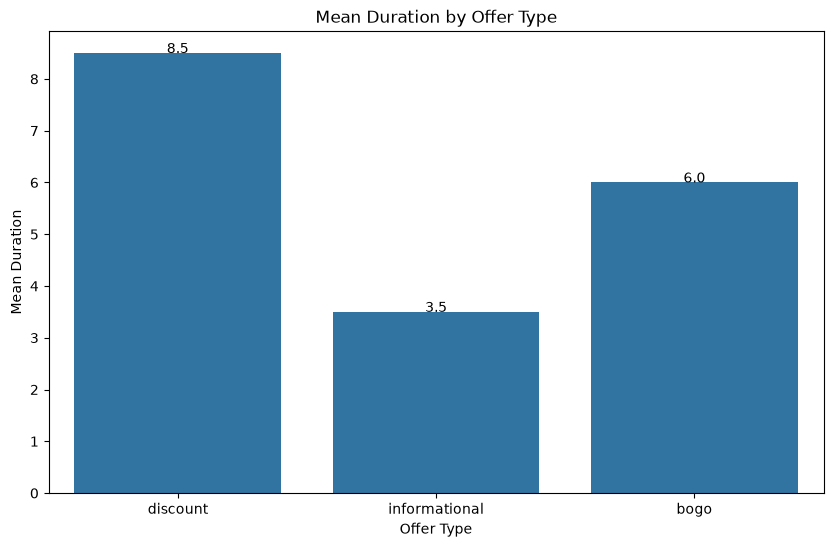

In [ ]:
# Grafico de barras da duração por tipo de oferta
duration_by_offer_type = (
    offers.groupBy("offer_type")
    .agg(F.mean("duration").alias("mean_duration"))
    .toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(x="offer_type", y="mean_duration", data=duration_by_offer_type)
plt.title("Mean Duration by Offer Type")
plt.xlabel("Offer Type")
plt.ylabel("Mean Duration")
for index, row in duration_by_offer_type.iterrows():
    plt.text(
        index,
        row["mean_duration"],
        round(row["mean_duration"], 2),
        color="black",
        ha="center",
    )
plt.show();

In [ ]:
offers.select("offer_type", "min_value", "duration", "discount_value").orderBy(
    "offer_type", "min_value"
).show(truncate=False)

+-------------+---------+--------+--------------+
|offer_type   |min_value|duration|discount_value|
+-------------+---------+--------+--------------+
|bogo         |5        |7.0     |5             |
|bogo         |5        |5.0     |5             |
|bogo         |10       |7.0     |10            |
|bogo         |10       |5.0     |10            |
|discount     |7        |7.0     |3             |
|discount     |10       |10.0    |2             |
|discount     |10       |7.0     |2             |
|discount     |20       |10.0    |5             |
|informational|0        |4.0     |0             |
|informational|0        |3.0     |0             |
+-------------+---------+--------+--------------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


<Axes: xlabel='min_value', ylabel='duration'>

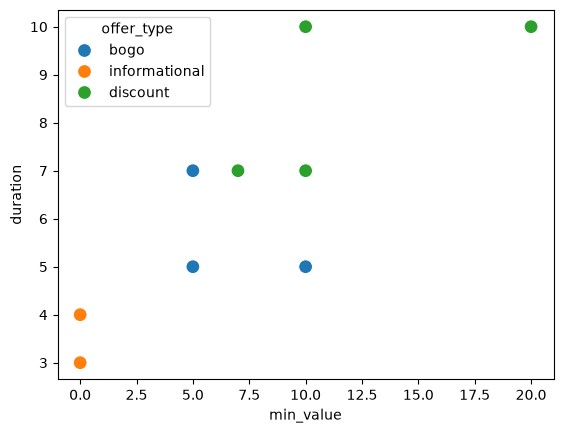

In [32]:
pdf = offers.select("offer_type", "min_value", "duration").toPandas()
sns.scatterplot(data=pdf, x="min_value", y="duration", hue="offer_type", s=100)

In [36]:
corr_discount = offers.filter(F.col("offer_type") == "discount").stat.corr(
    "min_value", "duration"
)
print(
    f"Correlação entre min_value e duration para ofertas de desconto: {corr_discount}"
)

Correlação entre min_value e duration para ofertas de desconto: 0.6608271381079536


In [ ]:
offers.withColumn(
    "generosity",
    F.when(F.col("min_value") == 0, None).otherwise(
        F.col("discount_value") / F.col("min_value")
    ),
).groupBy("offer_type").agg(
    F.min("generosity").alias("min_generosity"),
    F.max("generosity").alias("max_generosity"),
    F.mean("generosity").alias("avg_generosity"),
).show()

+-------------+--------------+-------------------+-------------------+
|   offer_type|min_generosity|     max_generosity|     avg_generosity|
+-------------+--------------+-------------------+-------------------+
|     discount|           0.2|0.42857142857142855|0.26964285714285713|
|informational|          NULL|               NULL|               NULL|
|         bogo|           1.0|                1.0|                1.0|
+-------------+--------------+-------------------+-------------------+

